In [31]:
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.holtwinters import SimpleExpSmoothing
from sklearn.metrics import mean_absolute_error, mean_squared_error


ruta_csv = Path("..") / "data" / "processed" / "Ventas_dia.csv"

# Cargar el CSV en un DataFrame
ventas = pd.read_csv(ruta_csv)
ventas["Fecha"]= pd.to_datetime(ventas["Fecha"])
ventas = ventas.set_index("Fecha")

print(ventas)

              Monto
Fecha              
1996-07-04   566.00
1996-07-05  2329.25
1996-07-08  3106.75
1996-07-09  4662.50
1996-07-10  1806.00
...             ...
1997-02-06   710.50
1997-02-07  1348.70
1997-02-10  9441.01
1997-02-11  2246.00
1997-02-12   673.20

[160 rows x 1 columns]


Cargamos la serie correspondiente a las ventas previamente extraída y limpiada.

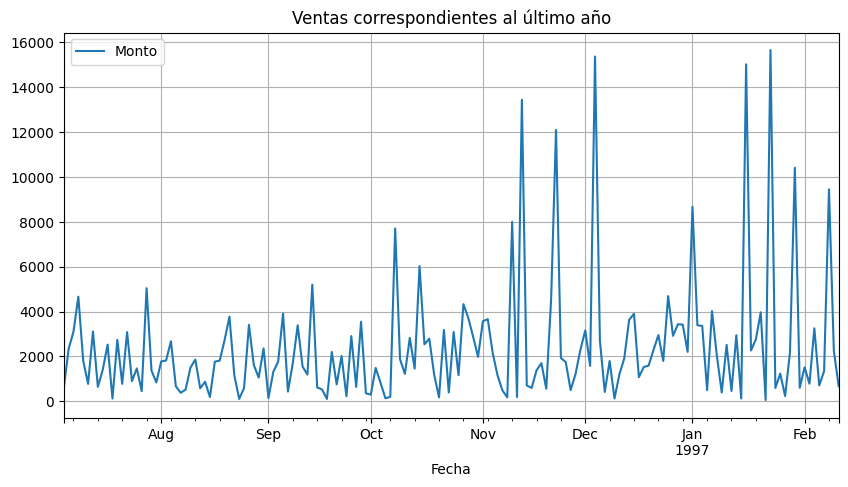

In [32]:
ventas.plot(figsize=(10, 5))
plt.title("Ventas correspondientes al último año")
plt.grid()
plt.show()

Como pudímos ver en el anáñisis EDA la serie es estacionaria, no hay tendencia y parece que tampoco hay estacionalidad por lo que el mejor modelo debe ser una suavización exponencial simple aunque antes notemos que da la impreción que la varianza aumenta con el tiempo y por lo que puede que se necesite aplicar alguna función logarítmica.

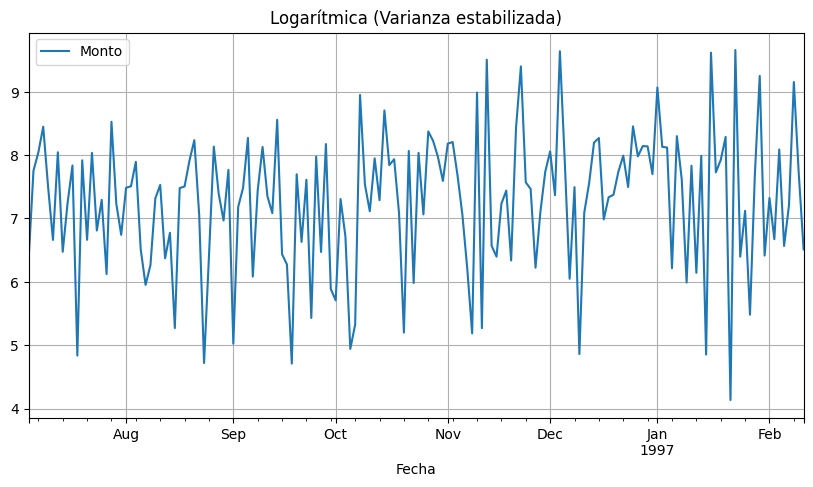

In [33]:
serie_log = np.log(ventas)

serie_log.plot(figsize=(10, 5))
plt.title("Logarítmica (Varianza estabilizada)")
plt.grid()
plt.show()

Veamos que la varianza se estabilizó con el logaritmo, veamos su función de autocorrelación y autocorrelación parcial.

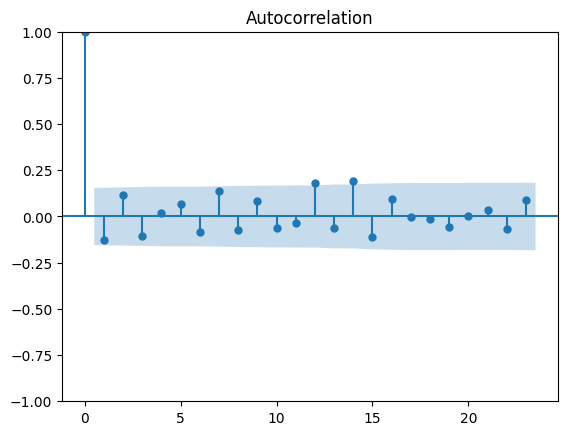

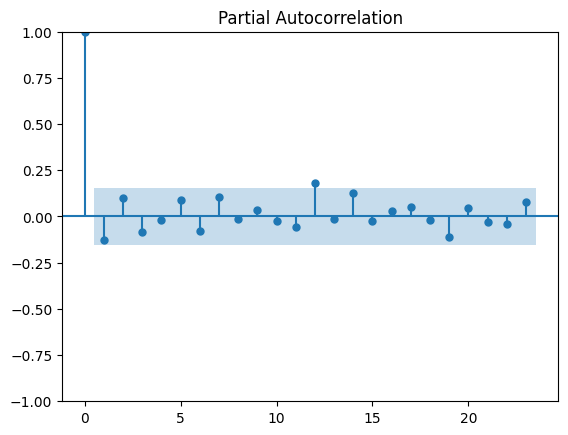

In [34]:
plot_acf(serie_log)
plt.show()

plot_pacf(serie_log)
plt.show()

Reafirmamos el hecho de que no hay estacionalidad y los valores nuevos no estan muy correlacionados con los pasados. La mejor opción sera una suavización exponencial simple.

In [39]:
train_size = int(len(serie_log) * 0.9)
train, test = serie_log[0:train_size], serie_log[train_size:len(serie_log)]

modelo = SimpleExpSmoothing(train, initialization_method="estimated").fit()
pronostico_test_log = modelo.forecast(len(test))
test_pronostico = np.exp(pronostico_test_log)
test_real = np.exp(test)
print("MAE", mean_absolute_error(test_pronostico, test_real))
print("RMSE", np.sqrt(mean_squared_error(test_pronostico, test_real)))

MAE 2658.3782335985798
RMSE 4605.37785009369


c:\Users\will\AppData\Local\Programs\Python\Python39\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)
